In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import joblib

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [13]:
# 2.1 Load training data
df = pd.read_csv(r"C:\Users\Machine learning Projects\APS Failure detection\aps_failure_training_set.csv")
print(df.shape)
df.head()


(60000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,0,37250,1432864,3664156,1007684,25896,0,2551696,0,0,0,0,0,4933296,3655166,1766008,1132040,0,0,0,0,1012,268,0,0,0,0,0,469014,4239660,703300,755876,0,5374,2108,4114,12348,615248,5526276,2378,4,0,0,2328746,1022304,415432,287230,310246,681504,1118814,3574,0,0,6700214,0,10,108,50,2551696,97518,947550,799478,330760,353400,299160,305200,283680,na,na,na,178540,76698.08,6700214,6700214,6599892,43566,68656,54064,638360,6167850,1209600,246244,2,96,0,5245752,0,916567.68,6,1924,0,0,0,118196,1309472,3247182,1381362,98822,11208,1608,220,240,6700214,na,10476,1226,267998,521832,428776,4015854,895240,26330,118,0,532,734,4122704,51288,0,532572,0,18,5330690,4732,1126,0,0,0,0,0,0,0,0,62282,85908,32790,0,0,202710,37928,14745580,1876644,0,0,0,0,2801180,2445.8,2712,965866,1706908,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,0,18254,653294,1720800,516724,31642,0,1393352,0,68,0,0,0,2560898,2127150,1084598,338544,0,0,0,0,0,0,0,0,0,0,0,71510,772720,1996924,99560,0,7336,7808,13776,13086,1010074,1873902,14726,6,0,0,1378576,447166,199512,154298,137280,138668,165908,229652,87082,4708,3646660,86,454,364,350,1393352,49028,688314,392208,341420,359780,366560,na,na,na,na,na,6700,33057.51,3646660,3646660,3582034,17733.0,260120,115626,6900,2942850,1209600,0,na,na,na,2291079.36,0,643536.96,0,0,0,0,38,98644,1179502,1286736,336388,36294,5192,56,na,0,3646660,na,6160,796,164860,350066,272956,1837600,301242,9148,22,0,na,na,na,na,na,na,na,na,na,3312,522,0,0,0,0,0,0,0,0,33736,36946,5936,0,0,103330,16254,4510080,868538,0,0,0,0,3477820,2211.76,2334,664504,824154,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,0,1648,370592,1883374,292936,12016,0,1234132,0,0,0,0,0,2371990,2173634,300796,153698,0,0,0,0,358,110,0,0,0,0,0,0,870456,239798,1450312,0,1620,1156,1228,34250,1811606,710672,34,0,0,0,790690,672026,332340,254892,189596,135758,103552,81666,46,0,2673338,128,202,576,4,1234132,28804,160176,139730,137160,130640,na,na,na,na,na,na,28000,41040.08,2673338,2673338,2678534,15439.0,7466,22436,248240,2560566,1209600,63328,0,124,0,2322692.16,0,236099.52,0,0,0,0,0,33276,1215280,1102798,196502,10260,2422,28,0,6,2673338,na,3584,500,56362,149726,100326,1744838,488302,16682,246,0,230,292,2180528,29188,22,20346,0,0,2341048,1494,152,0,0,0,0,0,0,0,0,13876,38182,8138,0,0,65772,10534,300240,48028,0,0,0,0,1040120,1018.64,1020,262032,453378,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,318,2212,3232,1872,0,0,0,2668,0,0,0,642,3894,10184,7554,10764,1014,0,0,0,0,60,6,0,0,0,0,0,0,0,2038,5596,0,64,6,6,914,76,2478,2398,1692,0,0,6176,340,304,102,74,406,216,16,0,0,21614,2,12,0,0,2668,184,7632,3090,na,na,na,na,na,na,na,na,10580,12.69,21614,21614,21772,32,50,1994,21400,7710,120960

## Data Cleaning

In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: int64(1), object(170)
memory usage: 78.3+ MB


### checking Na Values in dataset

In [17]:
na_counts = (df == "na").sum()
na_counts.head(20)
print("\nTotal 'na' in dataset:", na_counts.sum())



Total 'na' in dataset: 850015


Replacing na with actual NaN

In [18]:
df = df.replace("na", np.nan)


In [19]:
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2130706438,280,0,0,0,0,0,0,37250,1432864,3664156,1007684,25896,0,2551696,0,0,0,0,0,4933296,3655166,1766008,1132040,0,0,0,0,1012,268,0,0,0,0,0,469014,4239660,703300,755876,0,5374,2108,4114,12348,615248,5526276,2378,4,0,0,2328746,1022304,415432,287230,310246,681504,1118814,3574,0,0,6700214,0,10,108,50,2551696,97518,947550,799478,330760,353400,299160,305200,283680,NaN,NaN,NaN,178540,76698.08,6700214,6700214,6599892,43566,68656,54064,638360,6167850,1209600,246244,2,96,0,5245752,0,916567.68,6,1924,0,0,0,118196,1309472,3247182,1381362,98822,11208,1608,220,240,6700214,NaN,10476,1226,267998,521832,428776,4015854,895240,26330,118,0,532,734,4122704,51288,0,532572,0,18,5330690,4732,1126,0,0,0,0,0,0,0,0,62282,85908,32790,0,0,202710,37928,14745580,1876644,0,0,0,0,2801180,2445.8,2712,965866,1706908,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,NaN,0,NaN,0,0,0,0,0,0,18254,653294,1720800,516724,31642,0,1393352,0,68,0,0,0,2560898,2127150,1084598,338544,0,0,0,0,0,0,0,0,0,0,0,71510,772720,1996924,99560,0,7336,7808,13776,13086,1010074,1873902,14726,6,0,0,1378576,447166,199512,154298,137280,138668,165908,229652,87082,4708,3646660,86,454,364,350,1393352,49028,688314,392208,341420,359780,366560,NaN,NaN,NaN,NaN,NaN,6700,33057.51,3646660,3646660,3582034,17733.0,260120,115626,6900,2942850,1209600,0,NaN,NaN,NaN,2291079.36,0,643536.96,0,0,0,0,38,98644,1179502,1286736,336388,36294,5192,56,NaN,0,3646660,NaN,6160,796,164860,350066,272956,1837600,301242,9148,22,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3312,522,0,0,0,0,0,0,0,0,33736,36946,5936,0,0,103330,16254,4510080,868538,0,0,0,0,3477820,2211.76,2334,664504,824154,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,NaN,228,100,0,0,0,0,0,0,1648,370592,1883374,292936,12016,0,1234132,0,0,0,0,0,2371990,2173634,300796,153698,0,0,0,0,358,110,0,0,0,0,0,0,870456,239798,1450312,0,1620,1156,1228,34250,1811606,710672,34,0,0,0,790690,672026,332340,254892,189596,135758,103552,81666,46,0,2673338,128,202,576,4,1234132,28804,160176,139730,137160,130640,NaN,NaN,NaN,NaN,NaN,NaN,28000,41040.08,2673338,2673338,2678534,15439.0,7466,22436,248240,2560566,1209600,63328,0,124,0,2322692.16,0,236099.52,0,0,0,0,0,33276,1215280,1102798,196502,10260,2422,28,0,6,2673338,NaN,3584,500,56362,149726,100326,1744838,488302,16682,246,0,230,292,2180528,29188,22,20346,0,0,2341048,1494,152,0,0,0,0,0,0,0,0,13876,38182,8138,0,0,65772,10534,300240,48028,0,0,0,0,1040120,1018.64,1020,262032,453378,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,318,2212,3232,1872,0,0,0,2668,0,0,0,642,3894,10184,7554,10764,1014,0,0,0,0,60,6,0,0,0,0,0,0,0,2038,5596,0,64,6,6,914,76,2478,2398,1692,0,0,6176,340,304,102,74,406,216,16,0,0,21614,2,12,0,0,2668,184,7632,3090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10580,12.69,2161

Converting feature columns to numeric

In [20]:
feature_cols = [c for c in df.columns if c != "class"]
df[feature_cols] = df[feature_cols].astype(float)


In [21]:
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698.0,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,1766008.0,1132040.0,0.0,0.0,0.0,0.0,1012.0,268.0,0.0,0.0,0.0,0.0,0.0,469014.0,4239660.0,703300.0,755876.0,0.0,5374.0,2108.0,4114.0,12348.0,615248.0,5526276.0,2378.0,4.0,0.0,0.0,2328746.0,1022304.0,415432.0,287230.0,310246.0,681504.0,1118814.0,3574.0,0.0,0.0,6700214.0,0.0,10.0,108.0,50.0,2551696.0,97518.0,947550.0,799478.0,330760.0,353400.0,299160.0,305200.0,283680.0,NaN,NaN,NaN,178540.0,76698.08,6700214.0,6700214.0,6599892.0,43566.0,68656.0,54064.0,638360.0,6167850.0,1209600.0,246244.0,2.0,96.0,0.0,5245752.00,0.0,916567.68,6.0,1924.0,0.0,0.0,0.0,118196.0,1309472.0,3247182.0,1381362.0,98822.0,11208.0,1608.0,220.0,240.0,6700214.0,NaN,10476.0,1226.0,267998.0,521832.0,428776.0,4015854.0,895240.0,26330.0,118.0,0.0,532.0,734.0,4122704.0,51288.0,0.0,532572.0,0.0,18.0,5330690.0,4732.0,1126.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62282.0,85908.0,32790.0,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058.0,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,1084598.0,338544.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71510.0,772720.0,1996924.0,99560.0,0.0,7336.0,7808.0,13776.0,13086.0,1010074.0,1873902.0,14726.0,6.0,0.0,0.0,1378576.0,447166.0,199512.0,154298.0,137280.0,138668.0,165908.0,229652.0,87082.0,4708.0,3646660.0,86.0,454.0,364.0,350.0,1393352.0,49028.0,688314.0,392208.0,341420.0,359780.0,366560.0,NaN,NaN,NaN,NaN,NaN,6700.0,33057.51,3646660.0,3646660.0,3582034.0,17733.0,260120.0,115626.0,6900.0,2942850.0,1209600.0,0.0,NaN,NaN,NaN,2291079.36,0.0,643536.96,0.0,0.0,0.0,0.0,38.0,98644.0,1179502.0,1286736.0,336388.0,36294.0,5192.0,56.0,NaN,0.0,3646660.0,NaN,6160.0,796.0,164860.0,350066.0,272956.0,1837600.0,301242.0,9148.0,22.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3312.0,522.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33736.0,36946.0,5936.0,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040.0,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,300796.0,153698.0,0.0,0.0,0.0,0.0,358.0,110.0,0.0,0.0,0.0,0.0,0.0,0.0,870456.0,239798.0,1450312.0,0.0,1620.0,1156.0,1228.0,34250.0,1811606.0,710672.0,34.0,0.0,0.0,0.0,790690.0,672026.0,332340.0,254892.0,189596.0,135758.0,103552.0,81666.0,46.0,0.0,2673338.0,128.0,202.0,576.0,4.0,1234132.0,28804.0,160176.0,139730.0,137160.0

In [24]:
df['class'].value_counts()


class
neg    59000
pos     1000
Name: count, dtype: int64

#### Encoding target (neg → 0, pos → 1)

In [25]:
df["class"] = df["class"].map({"neg": 0, "pos": 1})
df["class"].value_counts(), df["class"].value_counts(normalize=True)


(class
 0    59000
 1     1000
 Name: count, dtype: int64,
 class
 0    0.983333
 1    0.016667
 Name: proportion, dtype: float64)

##### Missing Values Analysis

Missing percentage per feature

In [26]:
missing_percent = df.isna().mean().sort_values(ascending=False)
missing_percent.head(20)


br_000    0.821067
bq_000    0.812033
bp_000    0.795667
bo_000    0.772217
ab_000    0.772150
cr_000    0.772150
bn_000    0.733483
bm_000    0.659150
bl_000    0.454617
bk_000    0.383900
ch_000    0.247683
co_000    0.247683
cg_000    0.247683
cf_000    0.247683
ad_000    0.247683
ct_000    0.230133
cu_000    0.230133
cv_000    0.230133
cx_000    0.230133
cy_000    0.230133
dtype: float64

Plotting  top 30 columns with most missing values

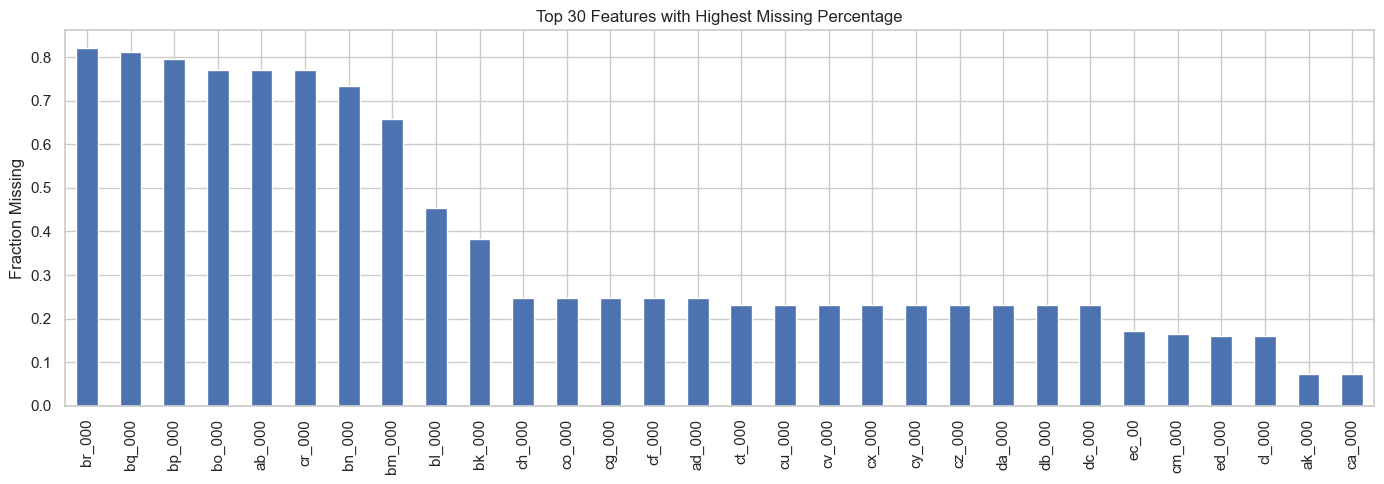

In [28]:
plt.figure(figsize=(14,5))
missing_percent.head(30).plot(kind='bar')
plt.title('Top 30 Features with Highest Missing Percentage')
plt.ylabel('Fraction Missing')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


#### Features like br_000, bq_000, bp_000… have >80% missing → very low information.

#### Features with 20–50% missing might still be useful with imputation.

#### Dropping columns with extremely high missingness

In [29]:
high_missing_cols = missing_percent[missing_percent > 0.8].index.tolist()
print("Columns to drop (missing > 80%):", len(high_missing_cols))

df = df.drop(columns=high_missing_cols)

print("New shape after dropping high-missing columns:", df.shape)

# Recompute missing percentages
feature_cols = [c for c in df.columns if c != 'class']
missing_percent = df[feature_cols].isna().mean().sort_values(ascending=False)
missing_percent.head(10)


Columns to drop (missing > 80%): 2
New shape after dropping high-missing columns: (60000, 169)


bp_000    0.795667
bo_000    0.772217
ab_000    0.772150
cr_000    0.772150
bn_000    0.733483
bm_000    0.659150
bl_000    0.454617
bk_000    0.383900
cf_000    0.247683
ad_000    0.247683
dtype: float64

To reduce noise and improve model stability, I removed features with more than 80% missing values, assuming they provide limited signal compared to their sparsity.

#### Target Imbalance – Detailed View

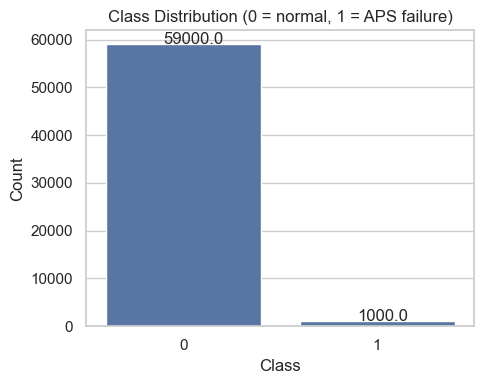

Class proportions:
 class
0    0.983333
1    0.016667
Name: proportion, dtype: float64


In [30]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x=df['class'])
plt.title('Class Distribution (0 = normal, 1 = APS failure)')
plt.xlabel('Class')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 200))

plt.tight_layout()
plt.show()

print("Class proportions:\n", df['class'].value_counts(normalize=True))


About 59k normal vs 1k failures → ~1.6% positive → strongly imbalanced.

Justify why you’ll use class_weight and cost-based evaluation later.

#### Correlation with Target (To Find Important Features)

In [31]:
corr_with_target = df.corr(numeric_only=True)['class'].sort_values(key=lambda x: x.abs(), ascending=False)
corr_with_target.head(20)


class     1.000000
ci_000    0.553308
bb_000    0.542744
bv_000    0.541598
bu_000    0.541598
cq_000    0.541598
bt_000    0.537452
aa_000    0.536978
aq_000    0.531135
bj_000    0.525249
ah_000    0.524591
an_000    0.524357
bg_000    0.522863
ao_000    0.519890
cc_000    0.519799
ap_000    0.515726
bx_000    0.512403
by_000    0.500328
bh_000    0.497385
dn_000    0.493186
Name: class, dtype: float64

#### Visualizing top 15 most correlated features

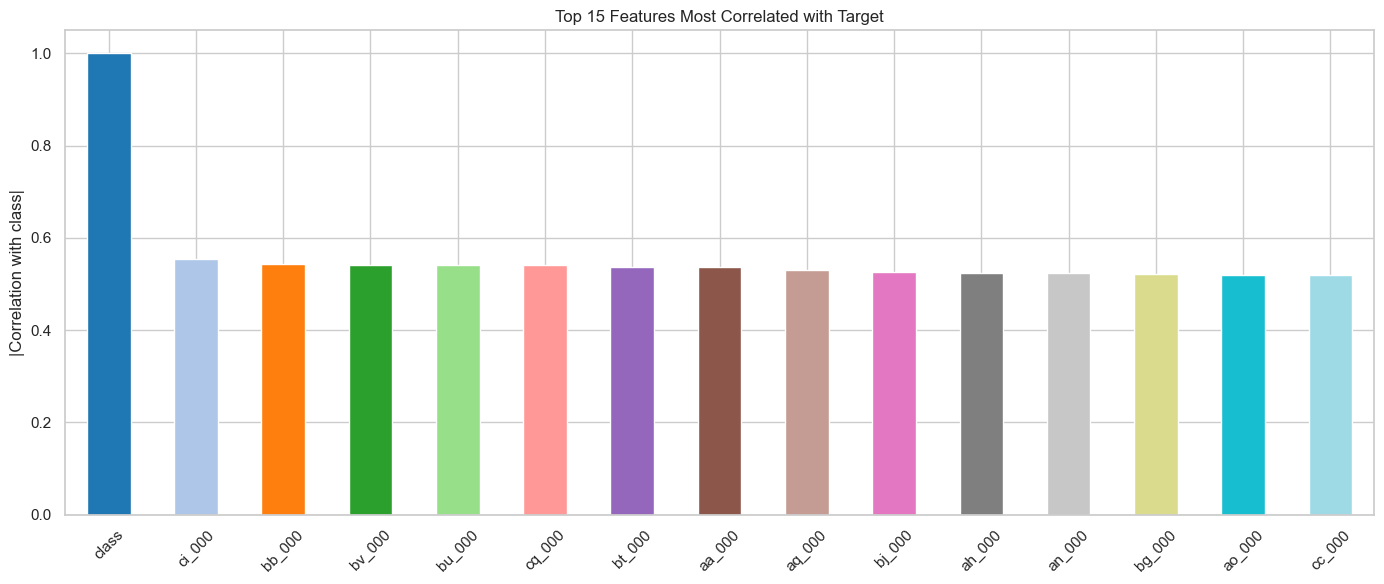

In [33]:
colors = plt.cm.tab20(np.linspace(0, 1, 15)) 

plt.figure(figsize=(14,6))
corr_with_target.abs().head(15).plot(kind='bar', color=colors)
plt.title('Top 15 Features Most Correlated with Target')
plt.ylabel('|Correlation with class|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

d_000, bb_000, bv_000, bu_000 — These show strong positive correlations, suggesting they may be directly linked to system failure patterns.

aq_000, bt_000, ba_000, az_000 — Moderate correlations indicate potential indirect influence or interaction effects.

bl_000, bi_000, ah_000, an_000, bg_000, ao_000, α_000 — These features, while less correlated, may still contribute valuable signal when combined in a multivariate model.

In [34]:
top_feats = corr_with_target.abs().head(6).index.tolist()
top_feats


['class', 'ci_000', 'bb_000', 'bv_000', 'bu_000', 'cq_000']

#### Histograms

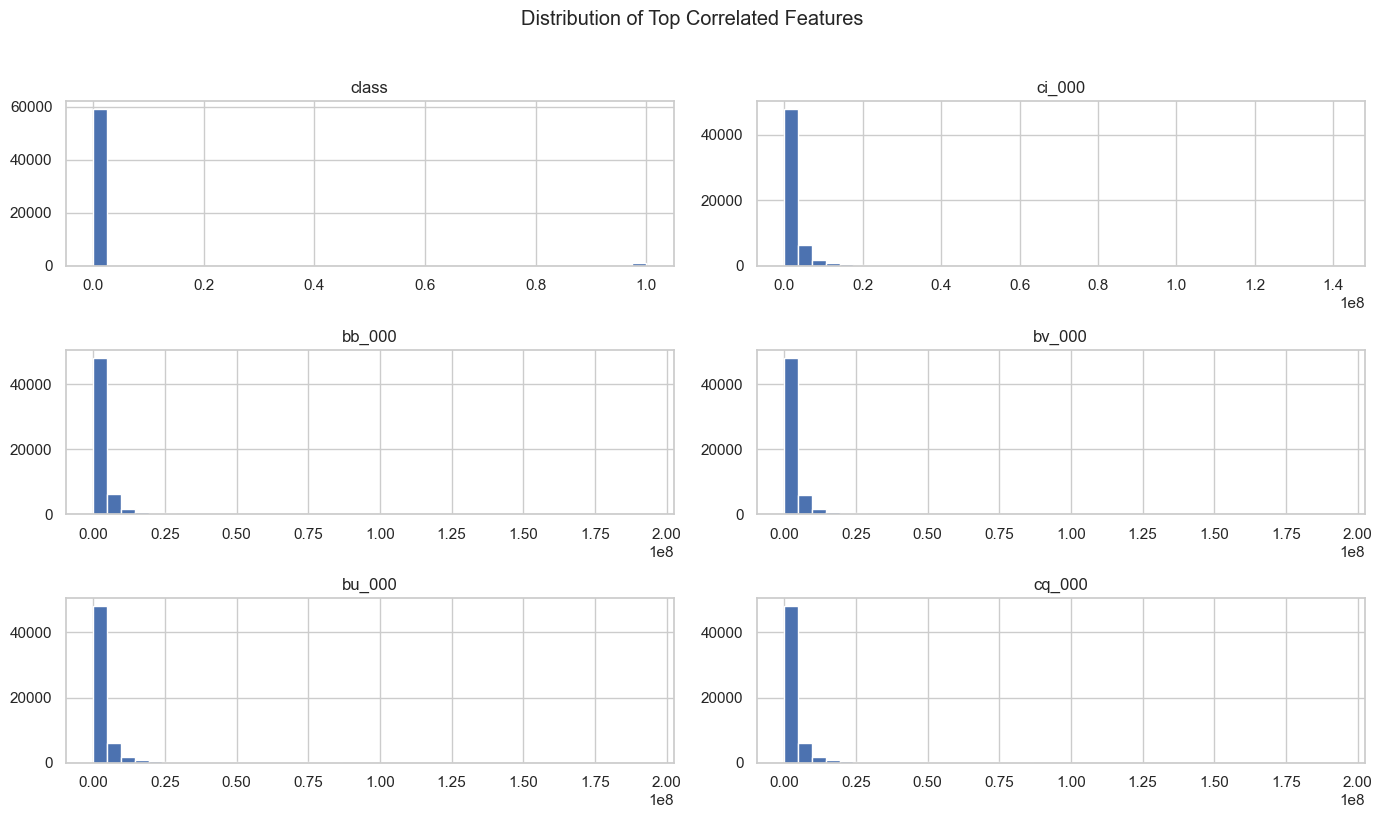

In [37]:

df[top_feats].hist(figsize=(14,8), bins=40)
plt.suptitle('Distribution of Top Correlated Features', y=1.02)
plt.tight_layout()
plt.show()


#### KDE plots separated by class (to show how failures differ)

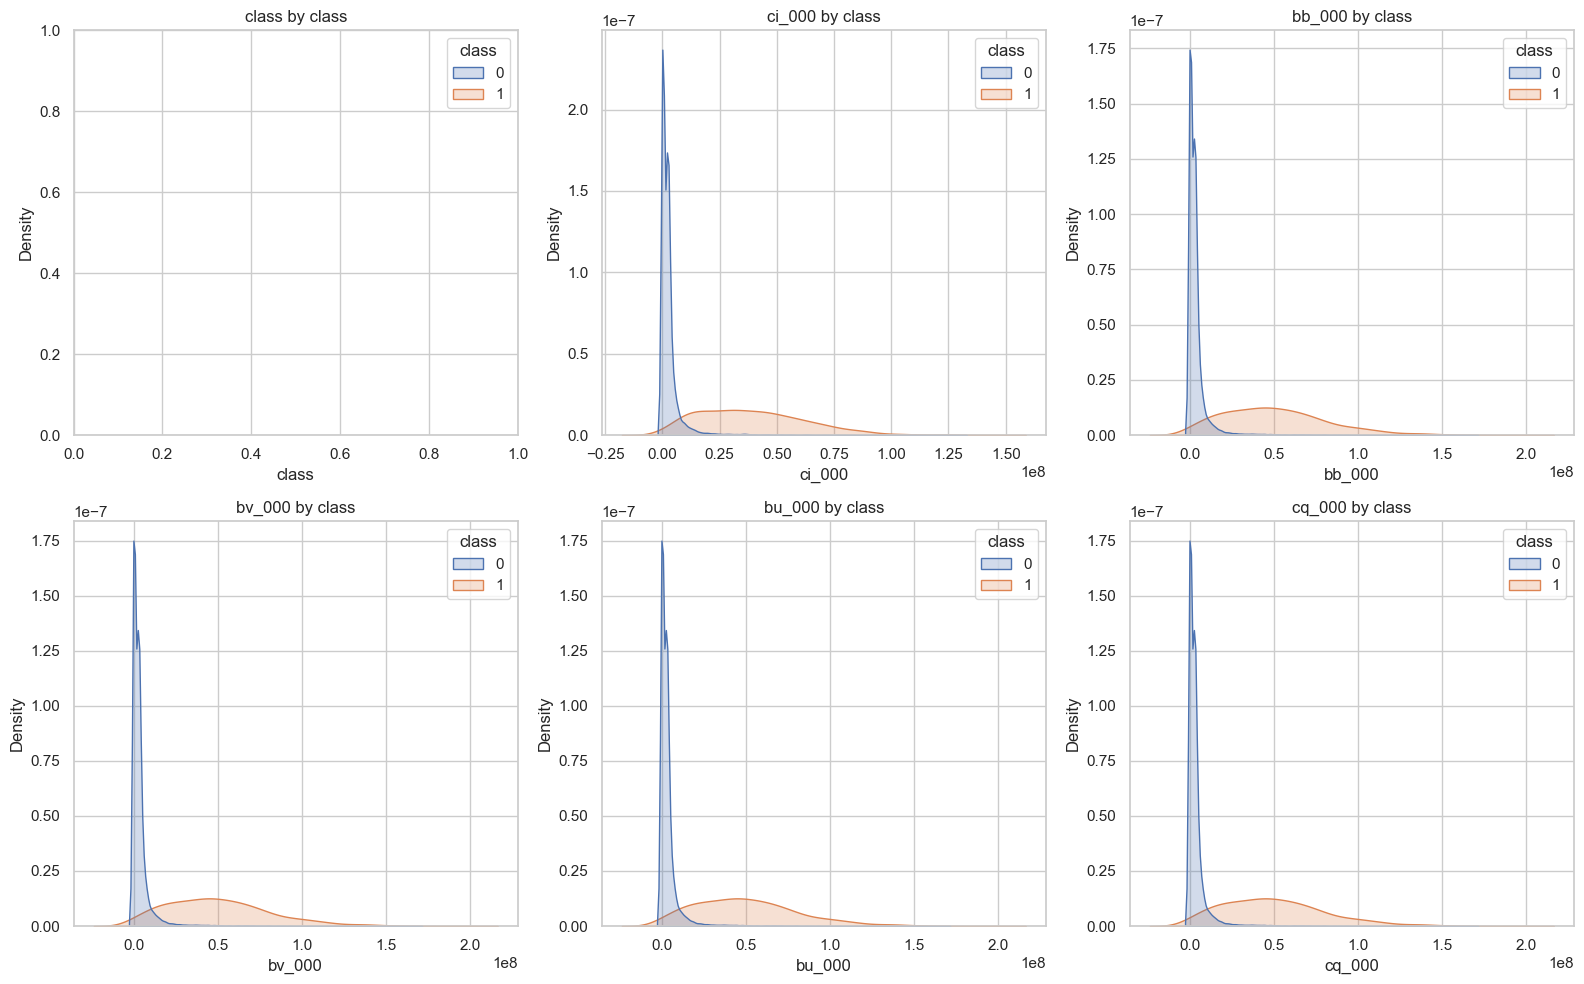

In [39]:
plt.figure(figsize=(16,10))
for i, col in enumerate(top_feats):
    plt.subplot(2,3,i+1)
    sns.kdeplot(data=df, x=col, hue='class', fill=True, common_norm=False,warn_singular=False)
    plt.title(f'{col} by class')
plt.tight_layout()
plt.show()


For several features, the density curves of class 0 and class 1 are clearly separated, meaning those sensors behave differently when an APS failure occurs.”

#### Boxplots by class (outliers & central tendency)

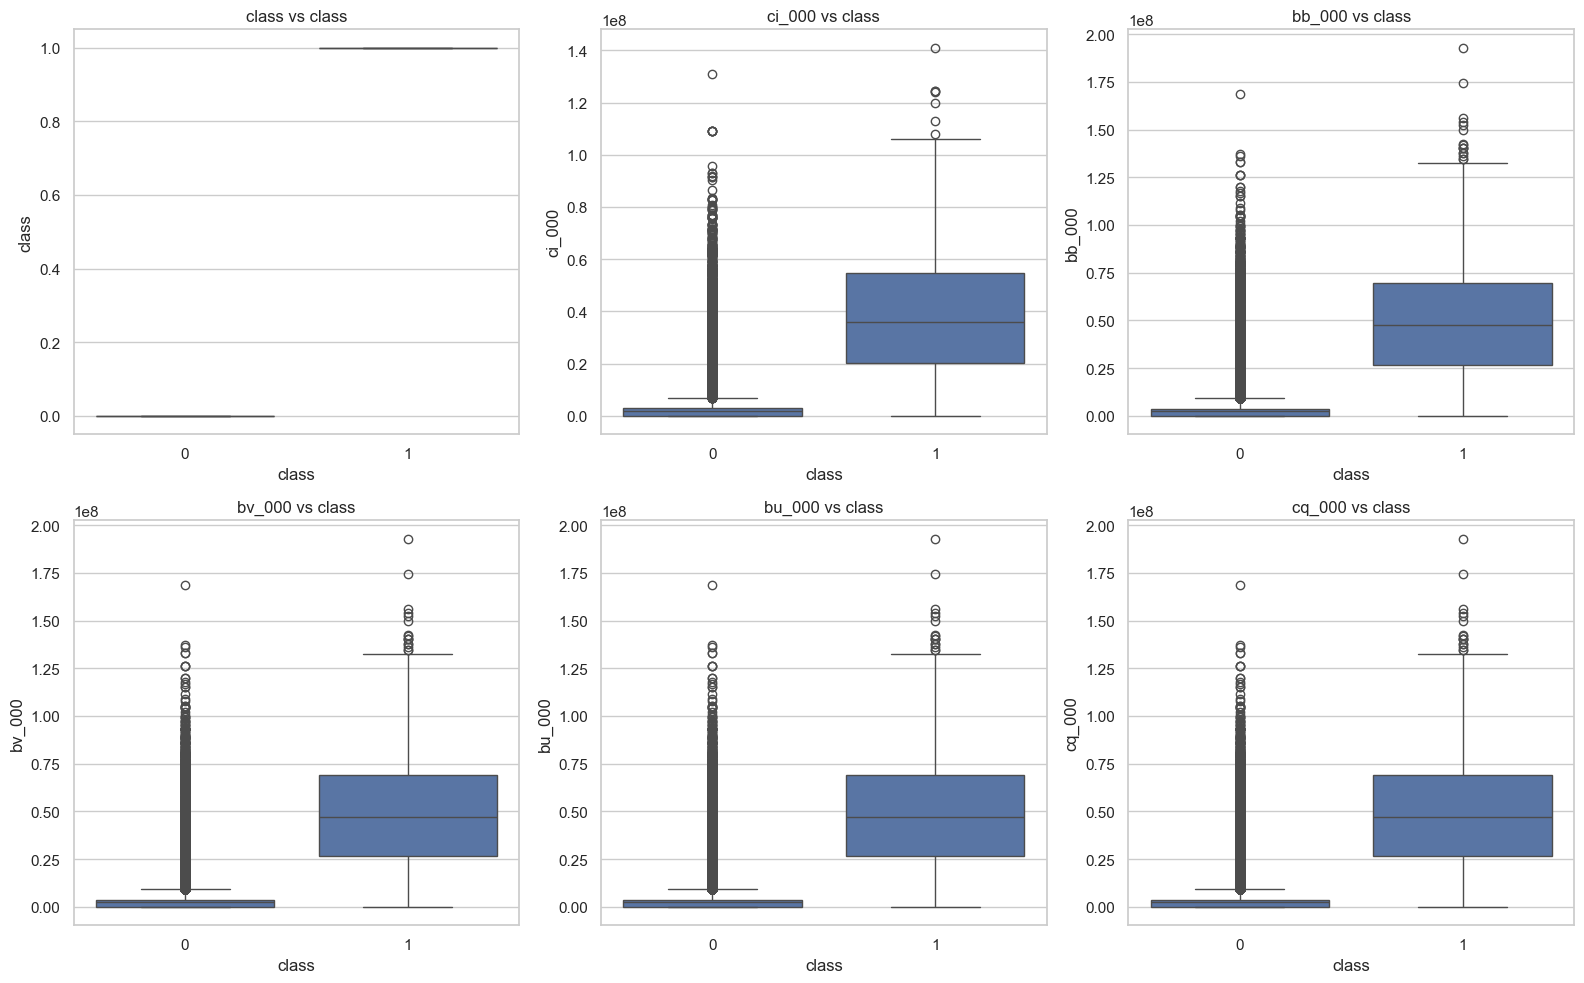

In [41]:
plt.figure(figsize=(16,10))
for i, col in enumerate(top_feats):
    plt.subplot(2,3,i+1)
    sns.boxplot(data=df, x='class', y=col)
    plt.title(f'{col} vs class')
plt.tight_layout()
plt.show()


### Feature Engineering

Missing count per row

In [42]:
df['missing_count'] = df.isna().sum(axis=1)


C:\Users\ADEEBSAYEED\AppData\Local\Temp\ipykernel_16880\1400330354.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['missing_count'] = df.isna().sum(axis=1)


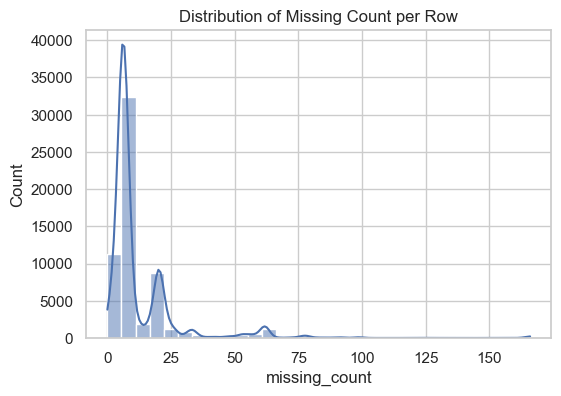

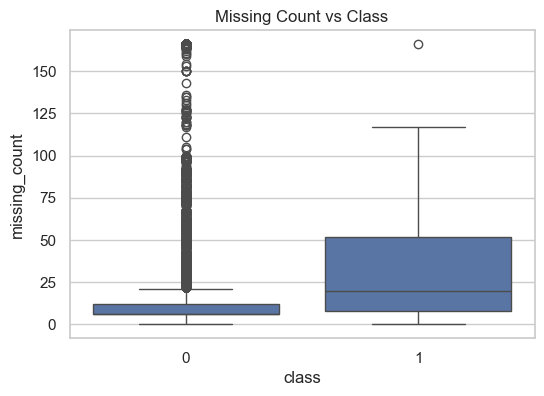

In [43]:
plt.figure(figsize=(6,4))
sns.histplot(df['missing_count'], bins=30, kde=True)
plt.title('Distribution of Missing Count per Row')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['class'], y=df['missing_count'])
plt.title('Missing Count vs Class')
plt.show()


Often, rows with failures might have different missingness patterns – this feature can help the model.

In [44]:
feature_cols = [c for c in df.columns if c != 'class']


### Train - Test - Split

In [46]:
X = df[feature_cols]
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())


Train class distribution:
 class
0    47200
1      800
Name: count, dtype: int64

Test class distribution:
 class
0    11800
1      200
Name: count, dtype: int64


#### Preprocessing Pipeline

In [47]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, feature_cols)
    ]
)


### Defining the APS Cost Function

The business metric Scania uses:

False Negative cost = 500 (missed failure → huge damage)

False Positive cost = 10 (unnecessary maintenance → minor cost)

In [55]:
def aps_cost_function(y_true, y_pred, fn_cost=500, fp_cost=10):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fn * fn_cost + fp * fp_cost
    return total_cost, cm


### Train & Evaluate Function

In [56]:
def train_and_evaluate(name, model):
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    cost, cm = aps_cost_function(y_test, y_pred)

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"APS Cost : {cost}")
    print("Confusion Matrix:\n", cm)
    
    return {
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'cost': cost
    }, pipe


In [57]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
    )
}


### Training ALL ML Models

In [58]:
results = []
pipelines = {}

for name, model in models.items():
    metrics, pipe = train_and_evaluate(name, model)
    results.append(metrics)
    pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by='cost')
results_df



===== Logistic Regression =====
Accuracy : 0.9714
Precision: 0.3595
Recall   : 0.9150
F1 Score : 0.5162
ROC-AUC  : 0.9647
APS Cost : 11760
Confusion Matrix:
 [[11474   326]
 [   17   183]]

===== Random Forest =====
Accuracy : 0.9920
Precision: 0.8881
Recall   : 0.5950
F1 Score : 0.7126
ROC-AUC  : 0.9931
APS Cost : 40650
Confusion Matrix:
 [[11785    15]
 [   81   119]]

===== Gradient Boosting =====
Accuracy : 0.9916
Precision: 0.7797
Recall   : 0.6900
F1 Score : 0.7321
ROC-AUC  : 0.9885
APS Cost : 31390
Confusion Matrix:
 [[11761    39]
 [   62   138]]

===== XGBoost =====
Accuracy : 0.9936
Precision: 0.7783
Recall   : 0.8600
F1 Score : 0.8171
ROC-AUC  : 0.9948
APS Cost : 14490
Confusion Matrix:
 [[11751    49]
 [   28   172]]


,model,accuracy,precision,recall,f1,roc_auc,cost
0,Logistic Regression,0.971417,0.359528,0.915,0.516220,0.964744,11760
3,XGBoost,0.993583,0.778281,0.860,0.817102,0.994767,14490
2,Gradient Boosting,0.991583,0.779661,0.690,0.732095,0.988523,31390
1,Random Forest,0.992000,0.888060,0.595,0.712575,0.993087,40650


Although XGBoost achieved the highest ROC-AUC (0.9947) and strong precision (0.78), Logistic Regression achieved the lowest APS cost (11,760) due to its superior recall (0.915).

Since the cost of missing a failure (FN = 500) is far greater than raising a false alarm (FP = 10), Logistic Regression performed best under the business cost metric defined in the original Scania APS problem.

#### Saving Best Model - Logistic Regression

In [59]:
best_model_name = "Logistic Regression"
best_pipeline = pipelines[best_model_name]

import joblib
joblib.dump(best_pipeline, "aps_best_model.pkl")

print("Best model saved as aps_best_model.pkl")


Best model saved as aps_best_model.pkl


### Confusion Matrix

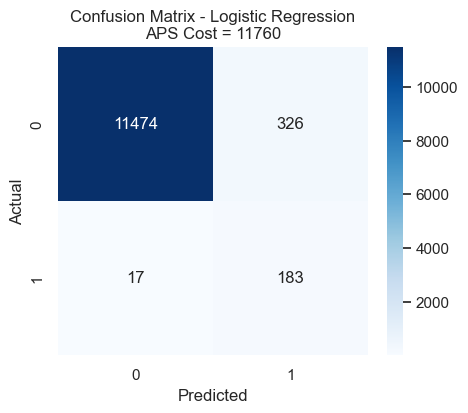

In [60]:
y_pred = best_pipeline.predict(X_test)
cost, cm = aps_cost_function(y_test, y_pred)

import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}\nAPS Cost = {cost}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
